##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]


---

## 0. Iteration setup

**Import libraries**

In [12]:
%pip install matplotlib
%pip install scikit-learn
%pip install jinja2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Load dataset(s)**

In [2]:
df = pd.read_csv('ships_inventory_iter1.csv')

---

## 1. Business Understanding

**Situation description**
Nebula Brokerage bepaalt de prijzen van ruimteschepen op dit moment door simpelweg te gokken en te schatten. Dit is een groot risico omdat ze hierdoor veel credits verliezen. Zeldzame schepen worden te goedkoop verkocht en normale schepen staan te lang stil omdat ze te duur zijn.

**Business objective(s)**
We hebben een datagedreven basis (baseline) nodig om te stoppen met gokken. We moeten veilig kunnen raden wat een schip waard is als we er niets over weten, om zo min mogelijk fouten te maken.

**Data mining goal(s)**
Dit is een regressie taak. We moeten namelijk een specifiek getal voorspellen: de verkoopprijs van een schip oftewel Galactic_Credits.

**Success criteria**
Het doel voor deze iteratie is een simpele basislijn maken met het gemiddelde en de mediaan. Het is een succes als we kunnen zien hoeveel deze simpele modellen gemiddeld fout zitten met de MAE en RMSE scores. Dit gebruiken we dan als startpunt om later te verbeteren.

---

## 2. Data Understanding

**Data exploration**
Hieronder bekijken we de basis statistieken en informatie over de kolommen. We gebruiken info() om te zien wat voor soort data we hebben, nummers of tekst en describe() voor het gemiddelde, min, max, enz.

In [ ]:
print("Data Informatie:")
df.info()
print("\nData Statistieken:")
display(df.describe())

Data Informatie:
<class 'pandas.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  str    
 4   Sector             368814 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 14.1 MB

Data Statistieken:


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000


**Visualizations and patterns**
We maken een histogram van de prijs Galactic_Credits. We zien dat de meeste schepen vrij goedkoop zijn en dat er maar een paar hele dure schepen zijn. De grafiek is scheef verdeeld.

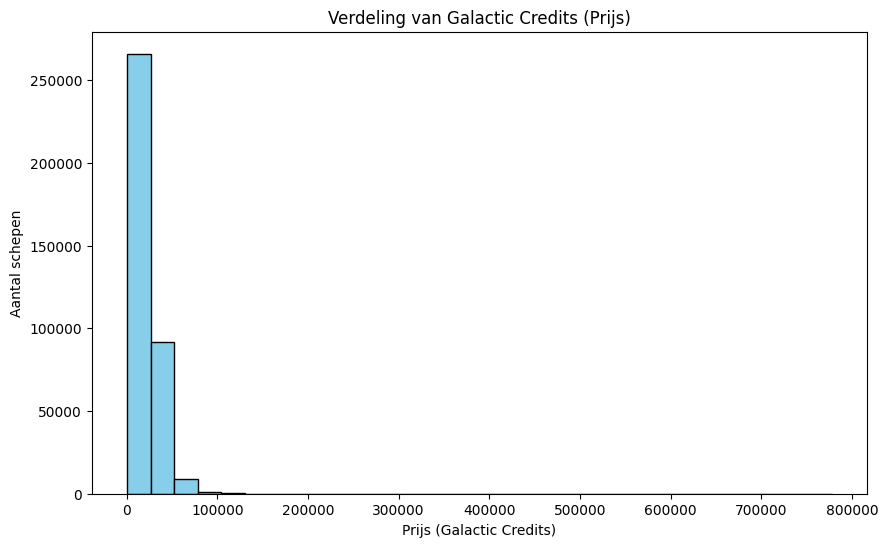

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['Galactic_Credits'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Verdeling van Galactic Credits (Prijs)')
plt.xlabel('Prijs (Galactic Credits)')
plt.ylabel('Aantal schepen')
plt.show()

**Data insights and data quality**
* **Data Exploration:** We zien drie soorten data: *gehele getallen* (voor Ship_ID, Galactic_Credits), *kommagetallen/floats* (voor Model_Cycle) en *tekst/objecten* (voor Ship_Manufacturer en Sector). De samenvattende statistieken tonen grote prijsverschillen: het goedkoopste schip is bijna gratis en het duurste schip kost tienduizenden credits meer dan gemiddeld.
* **Insights (verdeling en trends):** De histogram toont dat de data zeer "rechtsscheef" is ("right-skewed"). Dit betekent dat de markt voor tweedehands schepen vooral gedomineerd wordt door veel goedkope, massaproductie schepen, terwijl er maar een handjevol extreem dure, luxe of zeldzame schepen zijn.
* **Quality issues:** Voordat we kunnen voorspellen, gaan we hieronder via Python tellen hoeveel foutjes er in de data zitten. We controleren op dubbele gegevens, missende (lege) waarden, en we hebben handmatig in de data al een aantal spelfouten gespot (zoals "Galactic Motrs").

In [5]:
print("Aantal missende waarden (lege cellen):")
print(df.isnull().sum())
print("\nAantal dubbele rijen (duplicates):")
print(df.duplicated().sum())

Aantal missende waarden (lege cellen):
Ship_ID                 0
Galactic_Credits        0
Model_Cycle          7406
Ship_Manufacturer       0
Sector                  0
dtype: int64

Aantal dubbele rijen (duplicates):
500


---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
We gaan de data netjes maken zodat we er goed mee kunnen rekenen. Dit doen we in een paar simpele stappen:
1. Dubbele rijen weghalen.
2. Rijen met missende waardes (lege vakjes) verwijderen. Als we bijvoorbeeld missende bouwjaren opvullen met tekst zoals "Onbekend", weet de computer niet meer dat het een getallenkolom is en geeft dit later foutmeldingen.

In [6]:
df = df.drop_duplicates()
df = df.dropna()
print("Aantal rijen na het opschonen:", len(df))

Aantal rijen na het opschonen: 360916


**Adjusting dataset (optional)**
We zien in de data dat er veel spelfouten staan in de kolom met de naam van de fabrikant (Ship_Manufacturer). Zo heb je "Galactic_Motors", "Galactic Motrs", "Galactic Motors ", etc. Dit betekent allemaal hetzelfde bedrijf, maar de computer ziet het als verschillende categorieën. We gaan dit opschonen en alle afwijkende namen vervangen door de juiste spelwijze die we het meest tegenkomen.

Justification: Buiten het verwijderen van de lege en dubbele rijen hierboven, en het fixen van de spelfouten hieronder, hebben we bewust geen data verwijderd op basis van extreme waardes (outliers). Er zitten bijvoorbeeld een paar extreem dure schepen in de data. Omdat we voor onze eerste iteratie eerst een hele simpele basis willen neerzetten zonder moeilijke filters, laten we deze outliers voor nu gewoon staan in de dataset.

In [8]:
vervangingen = {
    'Galactic_Motors': 'Galactic Motors',
    'Galactic Motrs': 'Galactic Motors',
    'Galactic Motors ': 'Galactic Motors',
    'GALACTIC MOTORS': 'Galactic Motors',
    'Independent Shipwright': 'Independent Shipwrights',
    'Independent': 'Independent Shipwrights',
    'Ind. Shipwrights': 'Independent Shipwrights',
    'Corellian Eng.': 'Corellian Engineering',
    'Corellian Engineering Corp': 'Corellian Engineering',
    'Corelian Engineering': 'Corellian Engineering',
    'Nebula': 'Nebula Industries',
    'Nebula Ind': 'Nebula Industries',
    'Nebula Industries (c)': 'Nebula Industries',
    'Kuat  Drive Yards': 'Kuat Drive Yards',
    'Kuat Drive': 'Kuat Drive Yards',
    'Kuat DY': 'Kuat Drive Yards'
}
df['Ship_Manufacturer'] = df['Ship_Manufacturer'].replace(vervangingen)
print(df['Ship_Manufacturer'].unique())

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',               'Jumpship Corp']
Length: 12, dtype: str


---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
Om een startpunt ('baseline') te maken, gebruiken we nog geen slimme machine learning algoritmes. We gaan raden wat de prijs van een schip is op basis van twee hele simpele regressie modellen. We bouwen eigenlijk domme voorspellingsmodellen:
1. **Het Gemiddelde (Mean) model:** Dit model voorspelt voor *elk* nieuw schip (ongeacht fabrikant of cyclus) exact de gemiddelde prijs van alle schepen in onze dataset.
2. **Het Mediaan (Median) model:** Dit model voorspelt voor *elk* schip exact de middelste prijs van alle schepen in onze dataset (waarbij de helft goedkoper is, en de helft duurder).

Hiermee krijgen we we een goed gevoel of ingewikkeldere modellen in latere iteraties het eigenlijk wel beter doen dan domweg raden.

In [16]:
y_true = df['Galactic_Credits']

mean_price = y_true.mean()
median_price = y_true.median()

y_pred_mean = np.full(len(y_true), mean_price)
y_pred_median = np.full(len(y_true), median_price)

print(f"Het Gemiddelde model voorspelt voor altijd: {mean_price:.2f} credits.")
print(f"Het Mediaan model voorspelt altijd: {median_price:.2f} credits.")

Het Gemiddelde model voorspelt voor altijd: 19450.61 credits.
Het Mediaan model voorspelt altijd: 15990.00 credits.


**Testing and performance**
Dit is precies wat onze modellen voorspellen: de één gokt altijd het rekenkundig gemiddelde, en de ander gokt altijd de middelste prijs (mediaan). Omdat we weten wat de schepen *echt* kosten in onze dataset, kunnen we berekenen hoeveel onze dome modellen er gemiddeld naast zitten met twee scores:
* **MAE (Mean Absolute Error):** Hoeveel fouten maken we gemiddeld in absolute credits? Bijvoorbeeld: zitten we er gemiddeld 5.000 credits te duur of te goedkoop naast per schip?
* **RMSE (Root Mean Squared Error):** Hoeveel fouten maken we gemiddeld, maar grotere afwijkingen (zoals bij de paar extreem dure schepen) tellen veel zwaarder mee in de afstraffing.

Hieronder laten we de prestaties van beide modellen in een duidelijke tabel zien, waarbij we de `scikit-learn` metrics library gebruiken.

In [18]:
mae_mean = mean_absolute_error(y_true, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_true, y_pred_mean))

mae_median = mean_absolute_error(y_true, y_pred_median)
rmse_median = np.sqrt(mean_squared_error(y_true, y_pred_median))

table = pd.DataFrame({
    'Model': ['Gemiddelde Baseline', 'Mediaan Baseline'],
    'Voorspelde Prijs': [round(mean_price, 2), round(median_price, 2)],
    'MAE': [round(mae_mean, 2), round(mae_median, 2)],
    'RMSE': [round(rmse_mean, 2), round(rmse_median, 2)]
})
display(table)

,Model,Voorspelde Prijs,MAE,RMSE
0,Gemiddelde Baseline,19450.61,11605.56,15541.43
1,Mediaan Baseline,15990.00,11280.22,15922.06


---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
Uit de metrics (de MAE en RMSE scores uit Hoofdstuk 4) zien we dat beide "domme" voorspellingsmodellen er gemiddeld duizenden credits naast zitten bij het bepalen van de prijs. Wel zien we bij onze rechtsscheve data dat de Mediaan over het algemeen beter voorspelt (lagere foutscore) dan het absolute Gemiddelde. Dit komt doordat het gemiddelde erg omhoog getrokken wordt door een paar zeldzame, extreem dure schepen.

Desalniettemin is het "Success criteria" doel uit onze Business Understanding (Hoofdstuk 1) hiermee wel **behaald**. We wilden het wilde gokken kwantificeren, berekenen hoeveel Nebula Brokerage er nu naast zit, en een wiskundige basislijn (baseline) vaststellen. Dit is succesvol afgerond: we weten nu dat het nieuwe slimme Machine Learning model minstens beter moet gaan scoren dan de foutmarges in de bovenstaande tabel.

**Key findings and limitations**
* **Belangrijkste inzicht:** De schema's en tabellen lieten zien dat er gigantische prijsverschillen zitten tussen schepen (rechtsscheve verdeling). We kunnen dus simpelweg niet betrouwbaar 1 vaste baseline prijs plakken op elk schip in het universum, hierdoor lopen we heel veel credits mis.
* **Limitaties van dit model:** Deze Baseline kijkt alleen naar het prijskaartje en negeert alle andere informatie. Het is een gigantische beperking dat we de voorspelling nu totaal niet afstemmen op eigenschappen van het schip. In de volgende iteratie gaan we rekenen met `Model_Cycle` (leeftijd) en `Ship_Manufacturer` (merk). 
* **Extra benodigde data:** Om het model in de toekomst nog veel beter en nauwkeuriger te maken, zouden we eigenlijk **extra data** moeten verzamelen die nu nog ontbreekt in het systeem. Denk aan: de technische staat van het schip (schade), het aantal gemaakte vlucht-kilometers (mileage), wapen-upgrades of de hyperdrive klasse.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Achraf El Azzouzi | Hoofdstuk 1 (Business Understanding) & Hoofdstuk 2 (Data Understanding) | Geleerd hoe we een bedrijfsdoel vertalen naar een data doel. En ontdekt hoe we data inlezen, samenvatten en uittekenen met een histogram in Python. |
| Saeed Alhasan | Hoofdstuk 3 (Data Preparation) | Geleerd hoe belangrijk het is om missende data en dubbele rijen op te schonen. Ook geleerd hoe we typfouten in fabrikanten kunnen repareren met een dictionary in plaats van ingewikkelde functies. |
| Damian van der Sluis | Hoofdstuk 4 (Modeling) & Hoofdstuk 5 (Evaluation) | Begrepen hoe we een simpel basismodel (baseline) opzetten op basis van het gemiddelde en de mediaan. En geleerd hoe je de MAE en RMSE scores berekent en vertaalt naar een overzichtelijke tabel. |